In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pdfplumber

In [ ]:
!apt-get install -y tesseract-ocr tesseract-ocr-tur tesseract-ocr-eng poppler-utils
!pip install pytesseract pdf2image

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
tesseract-ocr-eng is already the newest version (1:4.00~git30-7274cfa-1.1).
tesseract-ocr-eng set to manually installed.
The following NEW packages will be installed:
  poppler-utils tesseract-ocr-tur
0 upgraded, 2 newly installed, 0 to remove and 2 not upgraded.
Need to get 1,764 kB of archives.
After this operation, 5,262 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-tur all 1:4.00~git30-7274cfa-1.1 [1,578 kB]
Fetched 1,764 kB in 1s (1,536 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpac

In [ ]:
import shutil
shutil.copy('/content/drive/MyDrive/tez_dataset.csv',
               '/content/drive/MyDrive/tez_dataset_BACKUP.csv')

'/content/drive/MyDrive/tez_dataset_BACKUP.csv'

In [ ]:
import os
import pdfplumber
import pandas as pd
import gc
from google.colab import drive

drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/tez_veri_seti"
output_csv = "/content/drive/MyDrive/tez_dataset.csv"

if os.path.exists(output_csv):
    print(" Mevcut CSV bulundu, kaldığı yerden devam ediliyor...")
    df_existing = pd.read_csv(output_csv)
    data = df_existing.values.tolist()
    processed_count = len(data)
    print(f"Daha önce {processed_count} dosya işlenmiş")
else:
    data = []
    processed_count = 0


save_interval = 5
counter = processed_count
processed_files = set()
if os.path.exists(output_csv):
    df_temp = pd.read_csv(output_csv)
    if 'filename' in df_temp.columns:
        processed_files = set(df_temp['filename'].tolist())

kategoriler = sorted([k for k in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, k))])

for kategori in kategoriler:
    kategori_path = os.path.join(base_path, kategori)

    if os.path.isdir(kategori_path):
        pdf_files = sorted([f for f in os.listdir(kategori_path) if f.endswith(".pdf")])
        print(f"\n📁 Kategori: {kategori} ({len(pdf_files)} PDF)")

        for file in pdf_files:
            file_id = f"{kategori}_{file}"

            if file_id in processed_files:
                continue

            pdf_path = os.path.join(kategori_path, file)

            try:
                text = ""
                with pdfplumber.open(pdf_path) as pdf:
                    for page in pdf.pages:
                        page_text = page.extract_text()
                        if page_text:
                            text += page_text + " "

                data.append([text, kategori, file_id])
                counter += 1

                print(f"  ✓ {counter}. dosya: {file[:50]}")

                if counter % save_interval == 0:
                    df = pd.DataFrame(data, columns=["text", "label", "filename"])
                    df.to_csv(output_csv, index=False, encoding='utf-8')
                    gc.collect()
                    print(f" Drive'a kaydedildi ({counter} dosya)")

            except Exception as e:
                print(f"   HATA - {file}: {str(e)[:100]}")

df = pd.DataFrame(data, columns=["text", "label", "filename"])
df.to_csv(output_csv)
print(f" Toplam işlenen dosya: {len(data)}")
print(f" Kaydedilen yer: {output_csv}")

print("\n Kategori Dağılımı:")
print(df['label'].value_counts().sort_index())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⚠️ Mevcut CSV bulundu, kaldığı yerden devam ediliyor...
Daha önce 115 dosya işlenmiş

📁 Kategori: biyokimya (100 PDF)
  ✓ 116. dosya: BIYO_0001.pdf...
  ✓ 117. dosya: BIYO_0002.pdf...
  ✓ 118. dosya: BIYO_0003.pdf...
  ✓ 119. dosya: BIYO_0004.pdf...
  ✓ 120. dosya: BIYO_0005.pdf...
  💾 Drive'a kaydedildi (120 dosya)
  ✓ 121. dosya: BIYO_0006.pdf...
  ✓ 122. dosya: BIYO_0007.pdf...
  ✓ 123. dosya: BIYO_0008.pdf...
  ✓ 124. dosya: BIYO_0009.pdf...
  ✓ 125. dosya: BIYO_0010.pdf...
  💾 Drive'a kaydedildi (125 dosya)
  ✓ 126. dosya: BIYO_0011.pdf...
  ✓ 127. dosya: BIYO_0012.pdf...
  ✓ 128. dosya: BIYO_0013.pdf...
  ✓ 129. dosya: BIYO_0014.pdf...
  ✓ 130. dosya: BIYO_0015.pdf...
  💾 Drive'a kaydedildi (130 dosya)
  ✓ 131. dosya: BIYO_0016.pdf...
  ✓ 132. dosya: BIYO_0017.pdf...
  ✓ 133. dosya: BIYO_0018.pdf...
  ✓ 134. dosya: BIYO_0019.pdf...
  ✓ 135. dosya: BIYO_

KeyboardInterrupt: 

In [ ]:
import os
import pdfplumber
import pandas as pd
import gc
from google.colab import drive

drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/tez_veri_seti"
output_csv = "/content/drive/MyDrive/tez_dataset.csv"

if os.path.exists(output_csv):
    print(" Mevcut CSV bulundu, Kimya klasörü ekleniyor...")
    df_existing = pd.read_csv(output_csv)
    data = df_existing.values.tolist()
    processed_count = len(data)
    print(f"Daha önce {processed_count} dosya işlenmiş")

    processed_files = set(df_existing['filename'].tolist())
else:
    print(" CSV dosyası bulunamadı")
    exit()

save_interval = 5
counter = processed_count

kategori = "kimya"
kategori_path = os.path.join(base_path, kategori)

if not os.path.exists(kategori_path):
    print(f" Kimya klasörü bulunamadı: {kategori_path}")
else:
    try:
        pdf_files = [f for f in os.listdir(kategori_path) if f.lower().endswith(".pdf")]
        print(f"\n Kategori: {kategori} ({len(pdf_files)} PDF)")

        yeni_eklenen = 0

        for file in pdf_files:
            file_id = f"{kategori}_{file}"

            if file_id in processed_files:
                print(f"    Atlandı: {file[:40]}...")
                continue

            pdf_path = os.path.join(kategori_path, file)

            try:
                text = ""
                with pdfplumber.open(pdf_path) as pdf:
                    for page in pdf.pages:
                        page_text = page.extract_text()
                        if page_text:
                            text += page_text + " "

                data.append([text, kategori, file_id])
                processed_files.add(file_id)
                counter += 1
                yeni_eklenen += 1

                print(f"  ✓ {counter}. dosya: {file[:50]}...")

                if yeni_eklenen % save_interval == 0:
                    df = pd.DataFrame(data, columns=["text", "label", "filename"])
                    df.to_csv(output_csv, index=False, encoding='utf-8')
                    gc.collect()
                    print(f" Drive'a kaydedildi ({counter} toplam dosya)")

            except Exception as e:
                print(f"   HATA - {file}: {str(e)[:100]}")

        print(f"\n Kimya klasöründen {yeni_eklenen} yeni dosya eklendi")

    except Exception as e:
        print(f" Kategori okuma hatası: {e}")

# Son kez kaydet
df = pd.DataFrame(data, columns=["text", "label", "filename"])
df.to_csv(output_csv, index=False, encoding='utf-8')

print(f"\n TAMAMLANDI!")
print(f" Toplam dosya sayısı: {len(data)}")
print(f" Kaydedilen yer: {output_csv}")

print("\n Kategori Dağılımı:")
print(df['label'].value_counts().sort_index())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Mevcut CSV bulundu, Kimya klasörü ekleniyor...
Daha önce 430 dosya işlenmiş

 Kategori: kimya (104 PDF)
  ✓ 431. dosya: KIM_0064.pdf...
  ✓ 432. dosya: KIM_0063.pdf...
  ✓ 433. dosya: KIM_0062.pdf...
  ✓ 434. dosya: KIM_0061.pdf...
  ✓ 435. dosya: KIM_0060.pdf...
 Drive'a kaydedildi (435 toplam dosya)
  ✓ 436. dosya: KIM_0059.pdf...
  ✓ 437. dosya: KIM_0058.pdf...
  ✓ 438. dosya: KIM_0057.pdf...
  ✓ 439. dosya: KIM_0056.pdf...
  ✓ 440. dosya: KIM_0055.pdf...
 Drive'a kaydedildi (440 toplam dosya)
  ✓ 441. dosya: KIM_0054.pdf...
  ✓ 442. dosya: KIM_0053.pdf...
  ✓ 443. dosya: KIM_0052.pdf...
  ✓ 444. dosya: KIM_0051.pdf...
  ✓ 445. dosya: KIM_0050.pdf...
 Drive'a kaydedildi (445 toplam dosya)
  ✓ 446. dosya: KIM_0049.pdf...
  ✓ 447. dosya: KIM_0048.pdf...
  ✓ 448. dosya: KIM_0047.pdf...
  ✓ 449. dosya: KIM_0046.pdf...
  ✓ 450. dosya: KIM_0045.pdf...
 Drive'a 

In [ ]:
import os
import pdfplumber
import pandas as pd
import gc
from google.colab import drive
from PIL import Image
import pytesseract
import io

drive.mount('/content/drive')

!apt-get install tesseract-ocr tesseract-ocr-tur -y

base_path = "/content/drive/MyDrive/tez_veri_seti"
output_csv = "/content/drive/MyDrive/tez_dataset.csv"

if os.path.exists(output_csv):
    df = pd.read_csv(output_csv)
    print(f" Toplam kayıt sayısı: {len(df)}")
else:
    print(" CSV dosyası bulunamadı")
    exit()

df['text_length'] = df['text'].astype(str).str.strip().str.len()
bos_satirlar = df[df['text_length'] < 100]
print(f"\n Boş veya çok kısa text içeren satır sayısı: {len(bos_satirlar)}")
print(f" Kategori dağılımı:\n{bos_satirlar['label'].value_counts()}")

def extract_text_with_ocr(pdf_path, max_pages=10):
    try:
        text = ""
        with pdfplumber.open(pdf_path) as pdf:
            total_pages = min(len(pdf.pages), max_pages)
            print(f" Toplam {len(pdf.pages)} sayfa var, ilk {total_pages} sayfa işlenecek")

            for page_num in range(total_pages):
                page = pdf.pages[page_num]

                page_text = page.extract_text()

                if page_text and len(page_text.strip()) > 50:
                    text += page_text + " "
                    print(f"    ✓ Sayfa {page_num+1}: Normal çıkarma ({len(page_text)} karakter)")
                else:
                    try:
                        pil_image = page.to_image(resolution=300).original

                        ocr_text = pytesseract.image_to_string(
                            pil_image,
                            lang='tur+eng',
                            config='--psm 6'
                        )

                        if ocr_text and len(ocr_text.strip()) > 20:
                            text += ocr_text + " "
                            print(f"    🔍 Sayfa {page_num+1}: OCR ile {len(ocr_text)} karakter çıkarıldı")
                    except Exception as ocr_error:
                        print(f"     Sayfa {page_num+1} OCR hatası: {str(ocr_error)[:50]}")

        return text.strip()
    except Exception as e:
        print(f"  Dosya okuma hatası: {str(e)[:100]}")
        return ""

save_interval = 5
guncellenen = 0
basarisiz = 0

for idx, row in bos_satirlar.iterrows():
    filename = row['filename']
    kategori = row['label']

    pdf_name = filename.replace(f"{kategori}_", "")
    pdf_path = os.path.join(base_path, kategori, pdf_name)

    if not os.path.exists(pdf_path):
        print(f" Dosya bulunamadı: {pdf_path}")
        continue

    print(f"\n {guncellenen + basarisiz + 1}. dosya işleniyor: {pdf_name[:50]}...")

    yeni_text = extract_text_with_ocr(pdf_path, max_pages=10)

    eski_text_uzunluk = len(str(row['text']).strip())
    yeni_text_uzunluk = len(yeni_text)

    if yeni_text_uzunluk > eski_text_uzunluk:
        df.at[idx, 'text'] = yeni_text
        guncellenen += 1
        print(f"  Güncellendi: {eski_text_uzunluk} → {yeni_text_uzunluk} karakter")

        if guncellenen % save_interval == 0:
            df_save = df.drop('text_length', axis=1)
            df_save.to_csv(output_csv, index=False, encoding='utf-8')
            gc.collect()
            print(f"  Drive'a kaydedildi ({guncellenen} dosya güncellendi)")
    else:
        basarisiz += 1
        print(f"   Yeterli metin çıkarılamadı (sadece {yeni_text_uzunluk} karakter)")

# Son kez kaydet
df_final = df.drop('text_length', axis=1)
df_final.to_csv(output_csv, index=False, encoding='utf-8')

print(f"\n TAMAMLANDI")
print(f" Toplam güncellenen dosya: {guncellenen}")
print(f" Başarısız dosya: {basarisiz}")
print(f" Kaydedilen yer: {output_csv}")

df_final['text_length_new'] = df_final['text'].astype(str).str.len()
print(f"\n Güncel durum:")
print(f"Ortalama text uzunluğu: {df_final['text_length_new'].mean():.0f} karakter")
print(f"100 karakterden kısa olanlar: {len(df_final[df_final['text_length_new'] < 100])}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
tesseract-ocr-tur is already the newest version (1:4.00~git30-7274cfa-1.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
 Mevcut CSV yükleniyor...
 Toplam kayıt sayısı: 534

 Boş veya çok kısa text içeren satır sayısı: 0
 Kategori dağılımı:
Series([], Name: count, dtype: int64)

 TAMAMLANDI!
 Toplam güncellenen dosya: 0
 Başarısız dosya: 0
 Kaydedilen yer: /content/drive/MyDrive/tez_dataset.csv

 Güncel durum:
Ortalama text uzunluğu: 162149 karakter
100 karakterden kısa olanlar: 0


In [ ]:
import pandas as pd

output_csv = "/content/drive/MyDrive/tez_dataset.csv"
df = pd.read_csv(output_csv)

print(f"\n Toplam dosya sayısı: {len(df)}")
print(f"\n Kategori dağılımı:")
print(df['label'].value_counts().sort_index())

print(f"\n Metin istatistikleri:")
df['text_length'] = df['text'].astype(str).str.len()
print(f"  • Ortalama: {df['text_length'].mean():.0f} karakter")
print(f"  • En kısa: {df['text_length'].min()} karakter")
print(f"  • En uzun: {df['text_length'].max()} karakter")
print(f"  • Medyan: {df['text_length'].median():.0f} karakter")

print(f"\nTüm dosyalarda text mevcut")
print(f" Veri seti model eğitimine hazır")
print(f"\n Dosya yolu: {output_csv}")


 Toplam dosya sayısı: 534

 Kategori dağılımı:
label
biyokimya    100
dahiliye     101
eczacılık    101
fizik        128
kimya        104
Name: count, dtype: int64

 Metin istatistikleri:
  • Ortalama: 162149 karakter
  • En kısa: 1525 karakter
  • En uzun: 935910 karakter
  • Medyan: 145504 karakter

Tüm dosyalarda text mevcut
 Veri seti model eğitimine hazır

 Dosya yolu: /content/drive/MyDrive/tez_dataset.csv


Mounted at /content/drive

Toplam kayıt: 534

Sütunlar: ['text', 'label', 'filename']

İlk 3 satır:
                                                text  label filename
0  2 BOYUTLU MALZEMELERİN TERMAL\nÖZELLİKLERİNİN ...  fizik      NaN
1  T.C.\nHACETTEPE ÜNİVERSİTESİ\nSAĞLIK BİLİMLERİ...  fizik      NaN
2  T.C.\nHACETTEPE ÜNİVERSİTESİ\nSAĞLIK BİLİMLERİ...  fizik      NaN
label
biyokimya    100
dahiliye     101
eczacılık    101
fizik        128
kimya        104
Name: count, dtype: int64


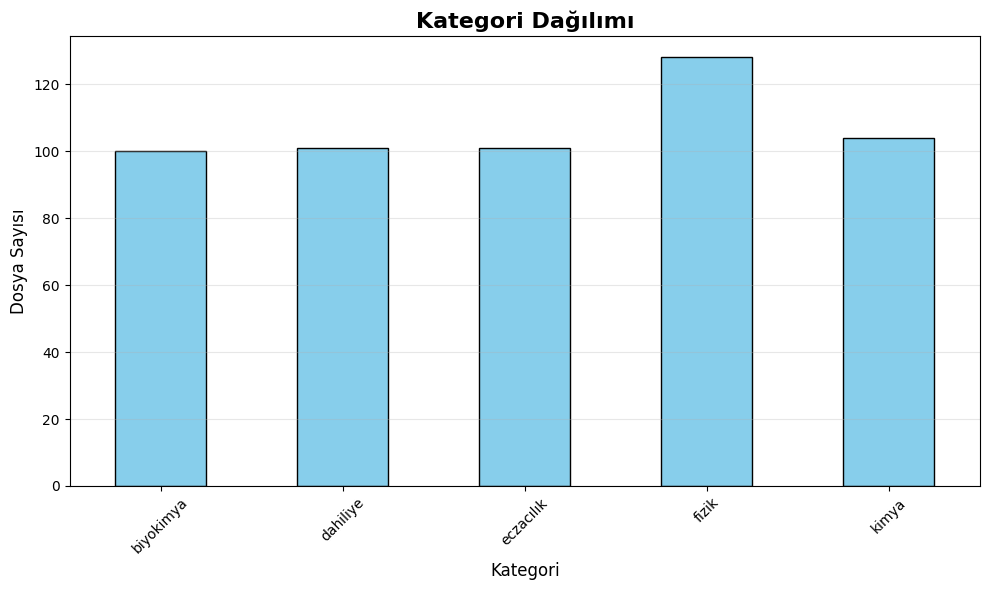

           count           mean            std      min        25%       50%  \
label                                                                          
biyokimya  100.0  154850.340000   56065.674366   1525.0  117859.75  143782.0   
dahiliye   101.0  130635.277228   46167.345445   5287.0  104204.00  126897.0   
eczacılık  101.0  204267.405941  111914.362265  11896.0  128063.00  174644.0   
fizik      128.0  145850.695312   65744.916987  41192.0  101018.50  146235.5   
kimya      104.0  178925.913462  116983.016703  41833.0  116345.00  142736.0   

                 75%       max  
label                           
biyokimya  189483.50  340579.0  
dahiliye   153769.00  289161.0  
eczacılık  237169.00  615876.0  
fizik      166007.00  501489.0  
kimya      202282.25  935910.0  


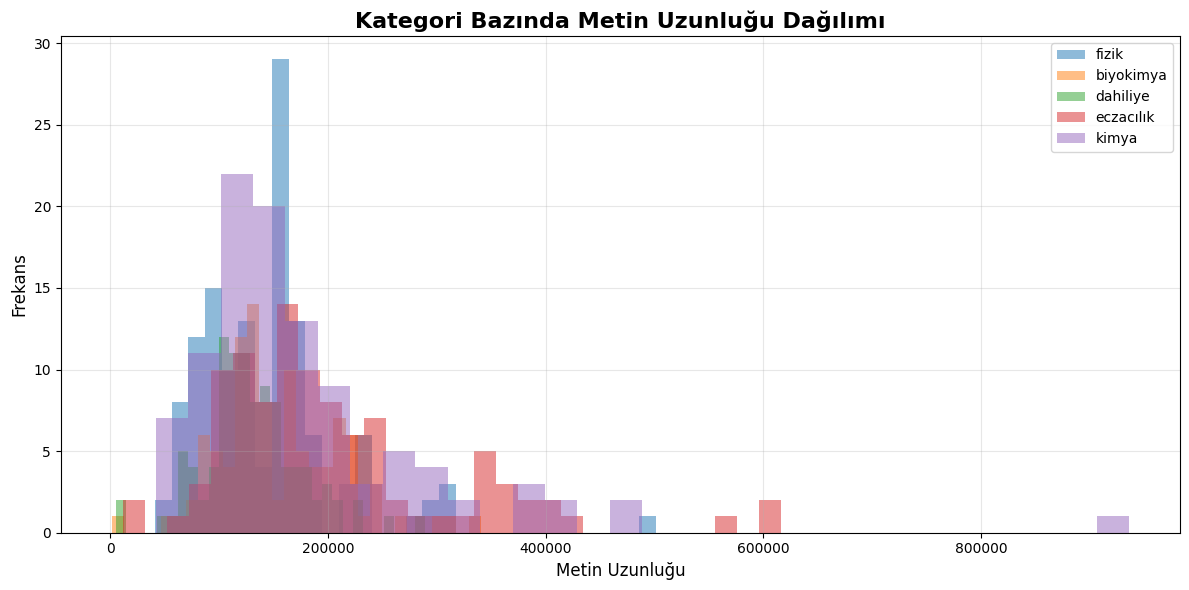

Train set: 427 (80.0%)
Test set: 107 (20.0%)

Train set kategori dağılımı:
label
biyokimya     80
dahiliye      81
eczacılık     81
fizik        102
kimya         83
Name: count, dtype: int64

Test set kategori dağılımı:
label
biyokimya    20
dahiliye     20
eczacılık    20
fizik        26
kimya        21
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/tez_dataset.csv")
print(f"\nToplam kayıt: {len(df)}")
print(f"\nSütunlar: {df.columns.tolist()}")
print(f"\nİlk 3 satır:")
print(df.head(3))
kategori_dagilim = df['label'].value_counts().sort_index()
print(kategori_dagilim)
plt.figure(figsize=(10, 6))
kategori_dagilim.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Kategori Dağılımı', fontsize=16, fontweight='bold')
plt.xlabel('Kategori', fontsize=12)
plt.ylabel('Dosya Sayısı', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

df['text_length'] = df['text'].astype(str).str.len()
print(df.groupby('label')['text_length'].describe())
plt.figure(figsize=(12, 6))
for kategori in df['label'].unique():
    subset = df[df['label'] == kategori]['text_length']
    plt.hist(subset, alpha=0.5, label=kategori, bins=30)
plt.title('Kategori Bazında Metin Uzunluğu Dağılımı', fontsize=16, fontweight='bold')
plt.xlabel('Metin Uzunluğu', fontsize=12)
plt.ylabel('Frekans', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Test set: {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")
print(f"\nTrain set kategori dağılımı:")
print(y_train.value_counts().sort_index())
print(f"\nTest set kategori dağılımı:")
print(y_test.value_counts().sort_index())

**MODEL 1: KLASİK MACHINE LEARNING**

 KLASIK MACHINE LEARNING MODELLERİ
   Feature sayısı: 5000
   Train shape: (427, 5000)
   Test shape: (107, 5000)
 MODEL EĞİTİMİ VE DEĞERLENDİRME
 Logistic Regression

  Eğitim süresi: 0.62 saniye
 Tahmin süresi: 0.00 saniye
 Accuracy: 0.8692 (86.92%)

 Classification Report:
              precision    recall  f1-score   support

   biyokimya       0.76      0.65      0.70        20
    dahiliye       0.72      0.90      0.80        20
   eczacılık       0.89      0.80      0.84        20
       fizik       1.00      1.00      1.00        26
       kimya       0.95      0.95      0.95        21

    accuracy                           0.87       107
   macro avg       0.87      0.86      0.86       107
weighted avg       0.87      0.87      0.87       107



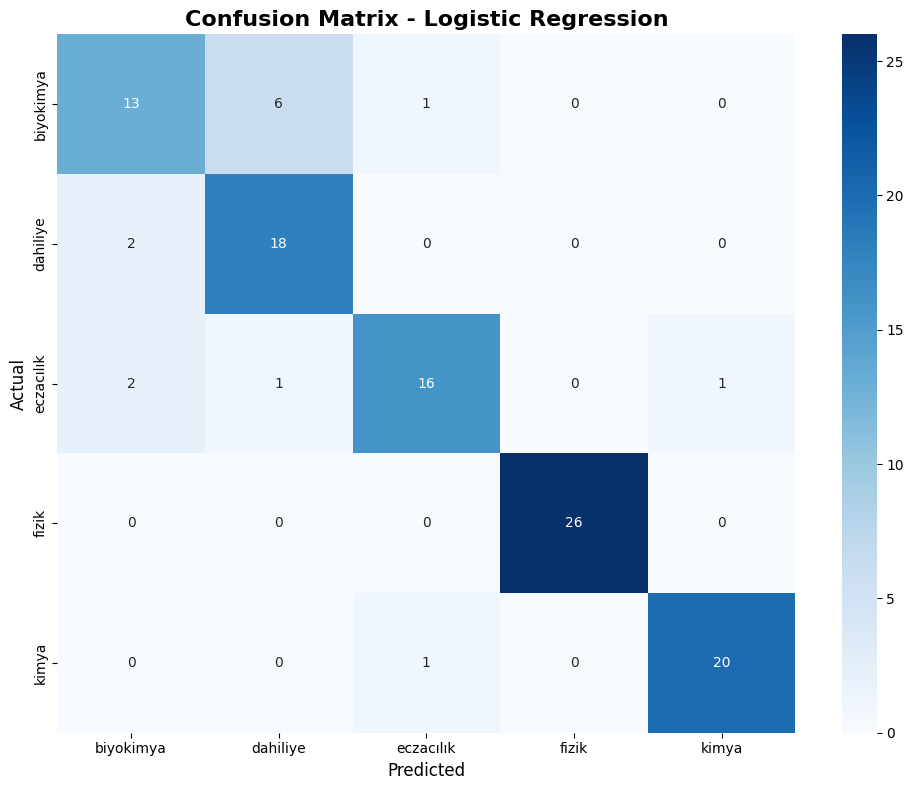

 SVM (Linear)

  Eğitim süresi: 4.20 saniye
 Tahmin süresi: 0.69 saniye
 Accuracy: 0.9065 (90.65%)

 Classification Report:
              precision    recall  f1-score   support

   biyokimya       0.78      0.90      0.84        20
    dahiliye       0.86      0.90      0.88        20
   eczacılık       0.94      0.80      0.86        20
       fizik       1.00      1.00      1.00        26
       kimya       0.95      0.90      0.93        21

    accuracy                           0.91       107
   macro avg       0.91      0.90      0.90       107
weighted avg       0.91      0.91      0.91       107



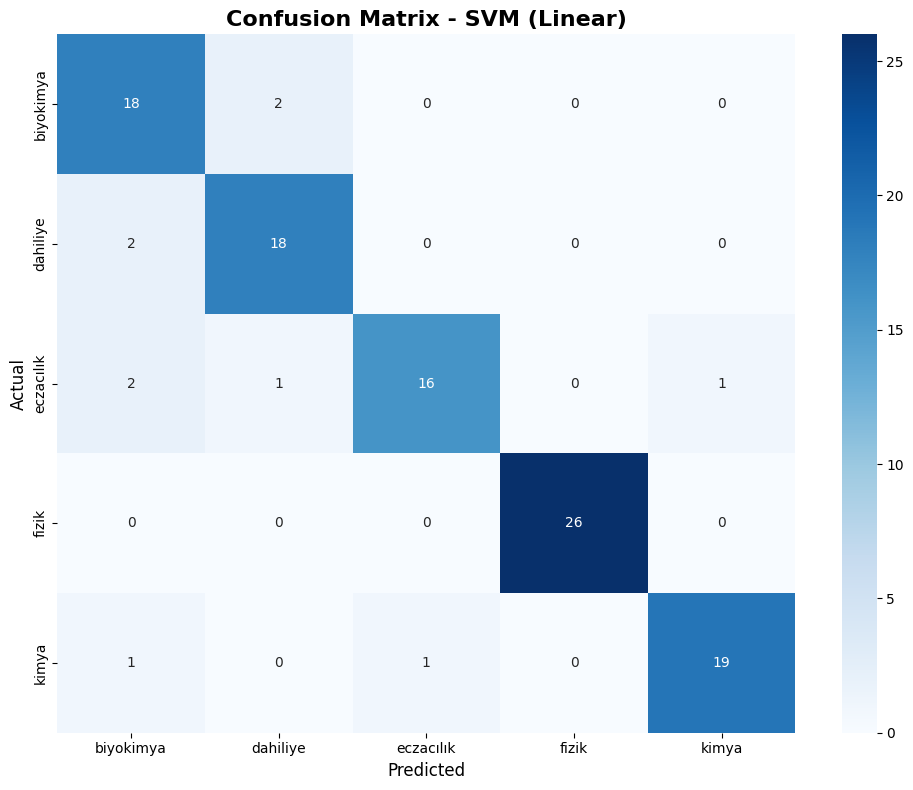

 Random Forest

  Eğitim süresi: 1.38 saniye
 Tahmin süresi: 0.06 saniye
 Accuracy: 0.9252 (92.52%)

 Classification Report:
              precision    recall  f1-score   support

   biyokimya       0.82      0.90      0.86        20
    dahiliye       0.83      0.95      0.88        20
   eczacılık       1.00      0.80      0.89        20
       fizik       1.00      1.00      1.00        26
       kimya       1.00      0.95      0.98        21

    accuracy                           0.93       107
   macro avg       0.93      0.92      0.92       107
weighted avg       0.93      0.93      0.93       107



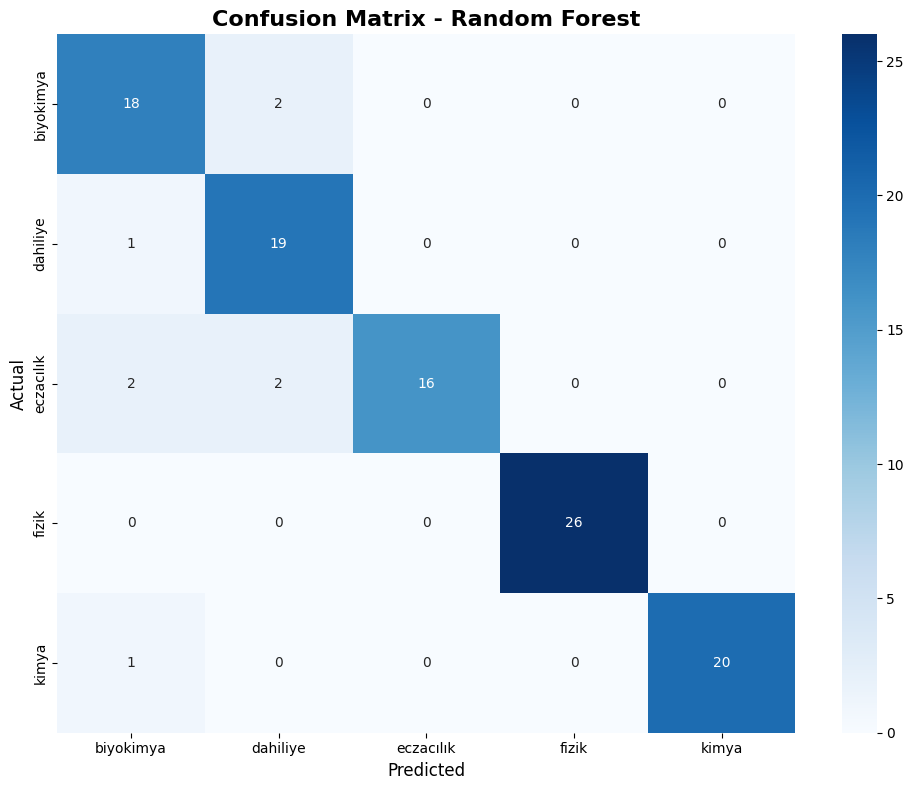

 Naive Bayes

  Eğitim süresi: 0.01 saniye
 Tahmin süresi: 0.00 saniye
 Accuracy: 0.8598 (85.98%)

 Classification Report:
              precision    recall  f1-score   support

   biyokimya       0.87      0.65      0.74        20
    dahiliye       0.69      1.00      0.82        20
   eczacılık       0.88      0.75      0.81        20
       fizik       0.96      1.00      0.98        26
       kimya       0.95      0.86      0.90        21

    accuracy                           0.86       107
   macro avg       0.87      0.85      0.85       107
weighted avg       0.88      0.86      0.86       107



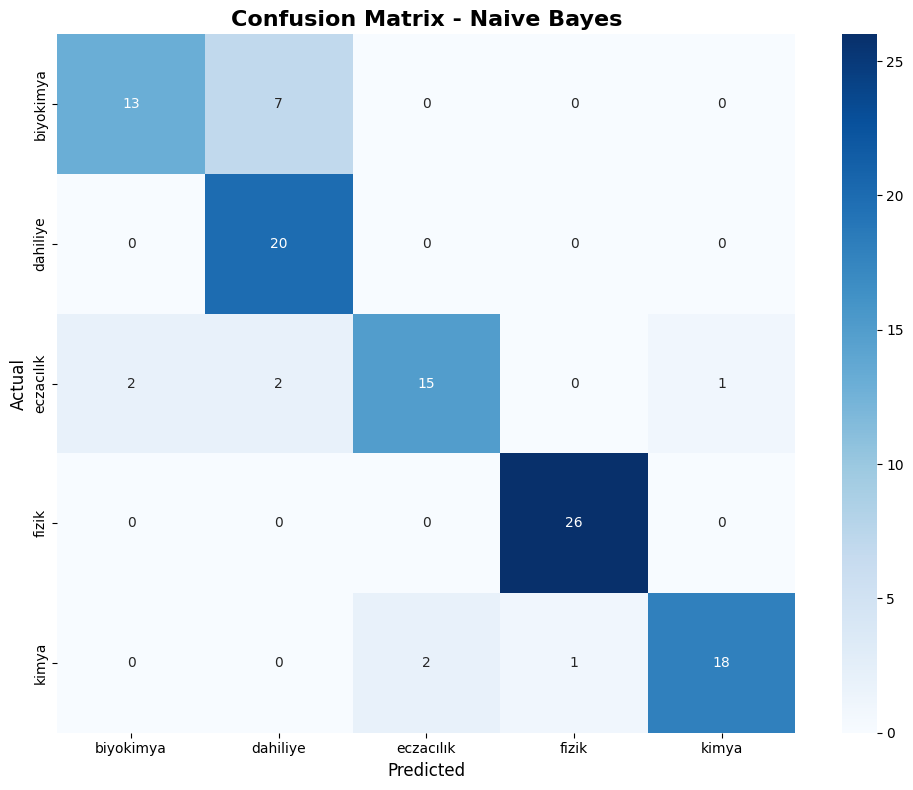

 MODEL KARŞILAŞTIRMASI
                     accuracy  train_time  predict_time
Random Forest        0.925234    1.381256      0.056189
SVM (Linear)         0.906542    4.195003      0.691571
Logistic Regression  0.869159    0.615947      0.002048
Naive Bayes          0.859813    0.013410      0.001632


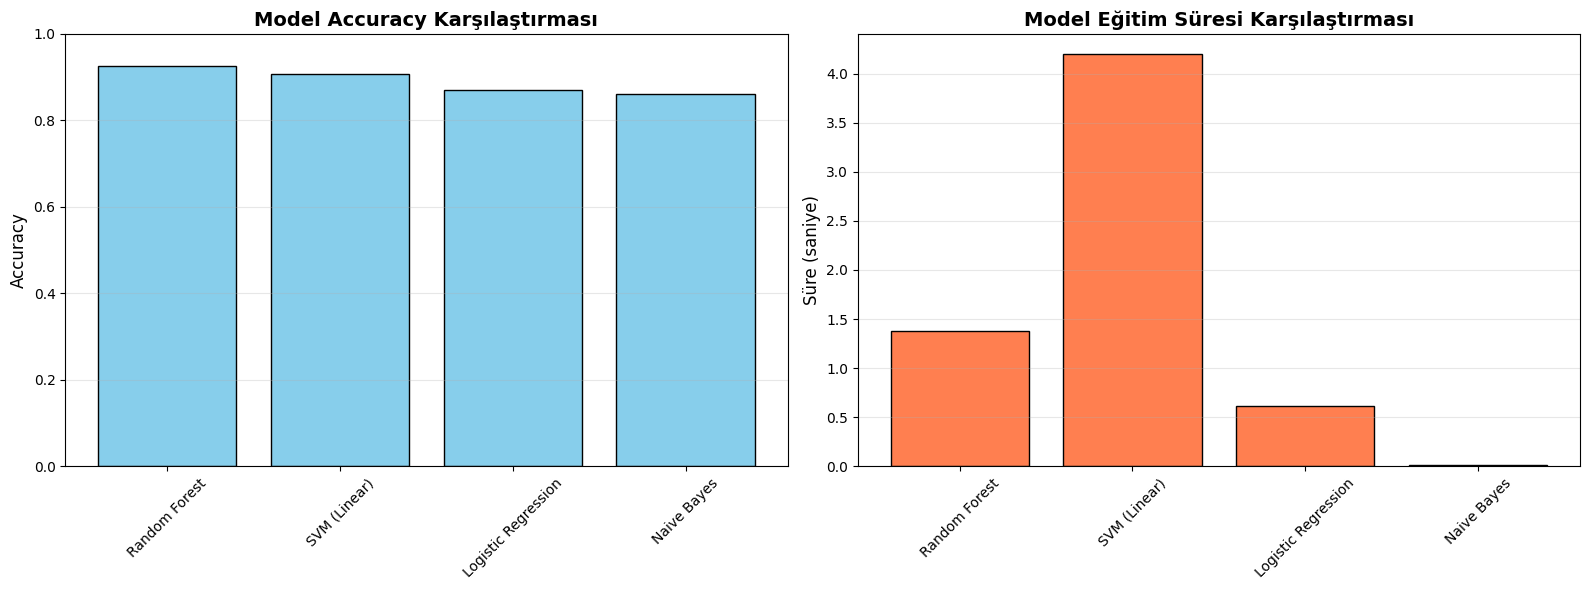

 En iyi model: Random Forest - Accuracy: 0.9252


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import time

print(" KLASIK MACHINE LEARNING MODELLERİ")
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"   Feature sayısı: {X_train_tfidf.shape[1]}")
print(f"   Train shape: {X_train_tfidf.shape}")
print(f"   Test shape: {X_test_tfidf.shape}")
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM (Linear)': SVC(kernel='linear', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes': MultinomialNB()
}
results = {}

print(" MODEL EĞİTİMİ VE DEĞERLENDİRME")
for model_name, model in models.items():
    print(f" {model_name}")
    start_time = time.time()
    model.fit(X_train_tfidf, y_train)
    train_time = time.time() - start_time

    start_time = time.time()
    y_pred = model.predict(X_test_tfidf)
    predict_time = time.time() - start_time
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\n  Eğitim süresi: {train_time:.2f} saniye")
    print(f" Tahmin süresi: {predict_time:.2f} saniye")
    print(f" Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

    print(f"\n Classification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, labels=sorted(y_test.unique()))
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=sorted(y_test.unique()),
                yticklabels=sorted(y_test.unique()))
    plt.title(f'Confusion Matrix - {model_name}', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.tight_layout()
    plt.show()

    results[model_name] = {
        'accuracy': accuracy,
        'train_time': train_time,
        'predict_time': predict_time
    }

print(" MODEL KARŞILAŞTIRMASI")
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.sort_values('accuracy', ascending=False)
print(comparison_df)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(comparison_df.index, comparison_df['accuracy'], color='skyblue', edgecolor='black')
axes[0].set_title('Model Accuracy Karşılaştırması', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_ylim([0, 1])
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(comparison_df.index, comparison_df['train_time'], color='coral', edgecolor='black')
axes[1].set_title('Model Eğitim Süresi Karşılaştırması', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Süre (saniye)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f" En iyi model: {comparison_df.index[0]} - Accuracy: {comparison_df.iloc[0]['accuracy']:.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TF-IDF Shape: (427, 5000)

HİPERPARAMETRE OPTİMİZASYONU - Logistic Regression
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Optimizasyon Süresi: 14.05 saniye

En iyi parametreler:
   C: 4.468327528535911
   solver: lbfgs

Cross-validation accuracy: 0.8595

Test Accuracy: 0.8879 (88.79%)

Classification Report:
              precision    recall  f1-score   support

   biyokimya       0.79      0.75      0.77        20
    dahiliye       0.78      0.90      0.84        20
   eczacılık       0.89      0.80      0.84        20
       fizik       1.00      1.00      1.00        26
       kimya       0.95      0.95      0.95        21

    accuracy                           0.89       107
   macro avg       0.88      0.88      0.88       107
weighted avg       0.89      0.89      0.89       107



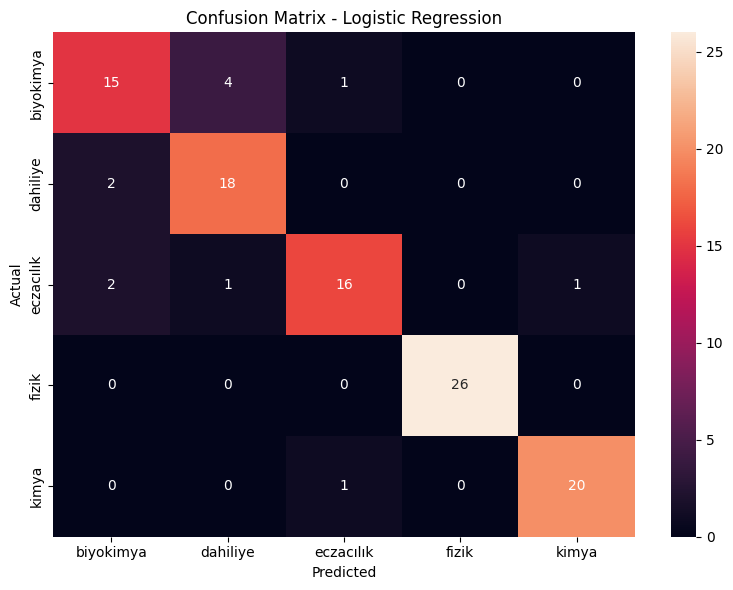

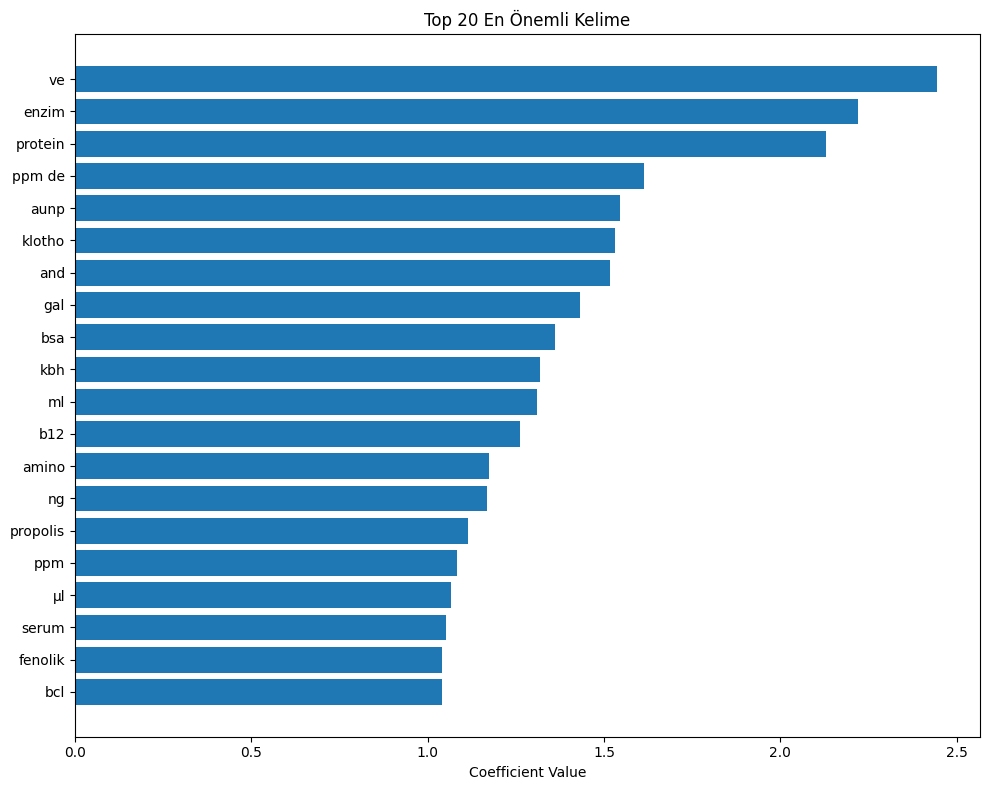

TÜM KATEGORİLER İÇİN EN ÖNEMLİ KELİMELER

🔹 BIYOKIMYA - En önemli 10 kelime:
   kbh                            → 1.3191
   bsa                            → 1.3611
   gal                            → 1.4333
   and                            → 1.5162
   klotho                         → 1.5303
   aunp                           → 1.5459
   ppm de                         → 1.6124
   protein                        → 2.1295
   enzim                          → 2.2215
   ve                             → 2.4439

🔹 DAHILIYE - En önemli 10 kelime:
   vitamin                        → 1.1682
   tanı                           → 1.1760
   hasta                          → 1.1928
   tiroid                         → 1.2301
   kan                            → 1.2436
   tedavi                         → 1.3973
   klinik                         → 1.4669
   anlamlı                        → 1.5216
   hastaların                     → 2.0428
   hastalarda                     → 2.1229

🔹 ECZACILIK - En önemli 10 

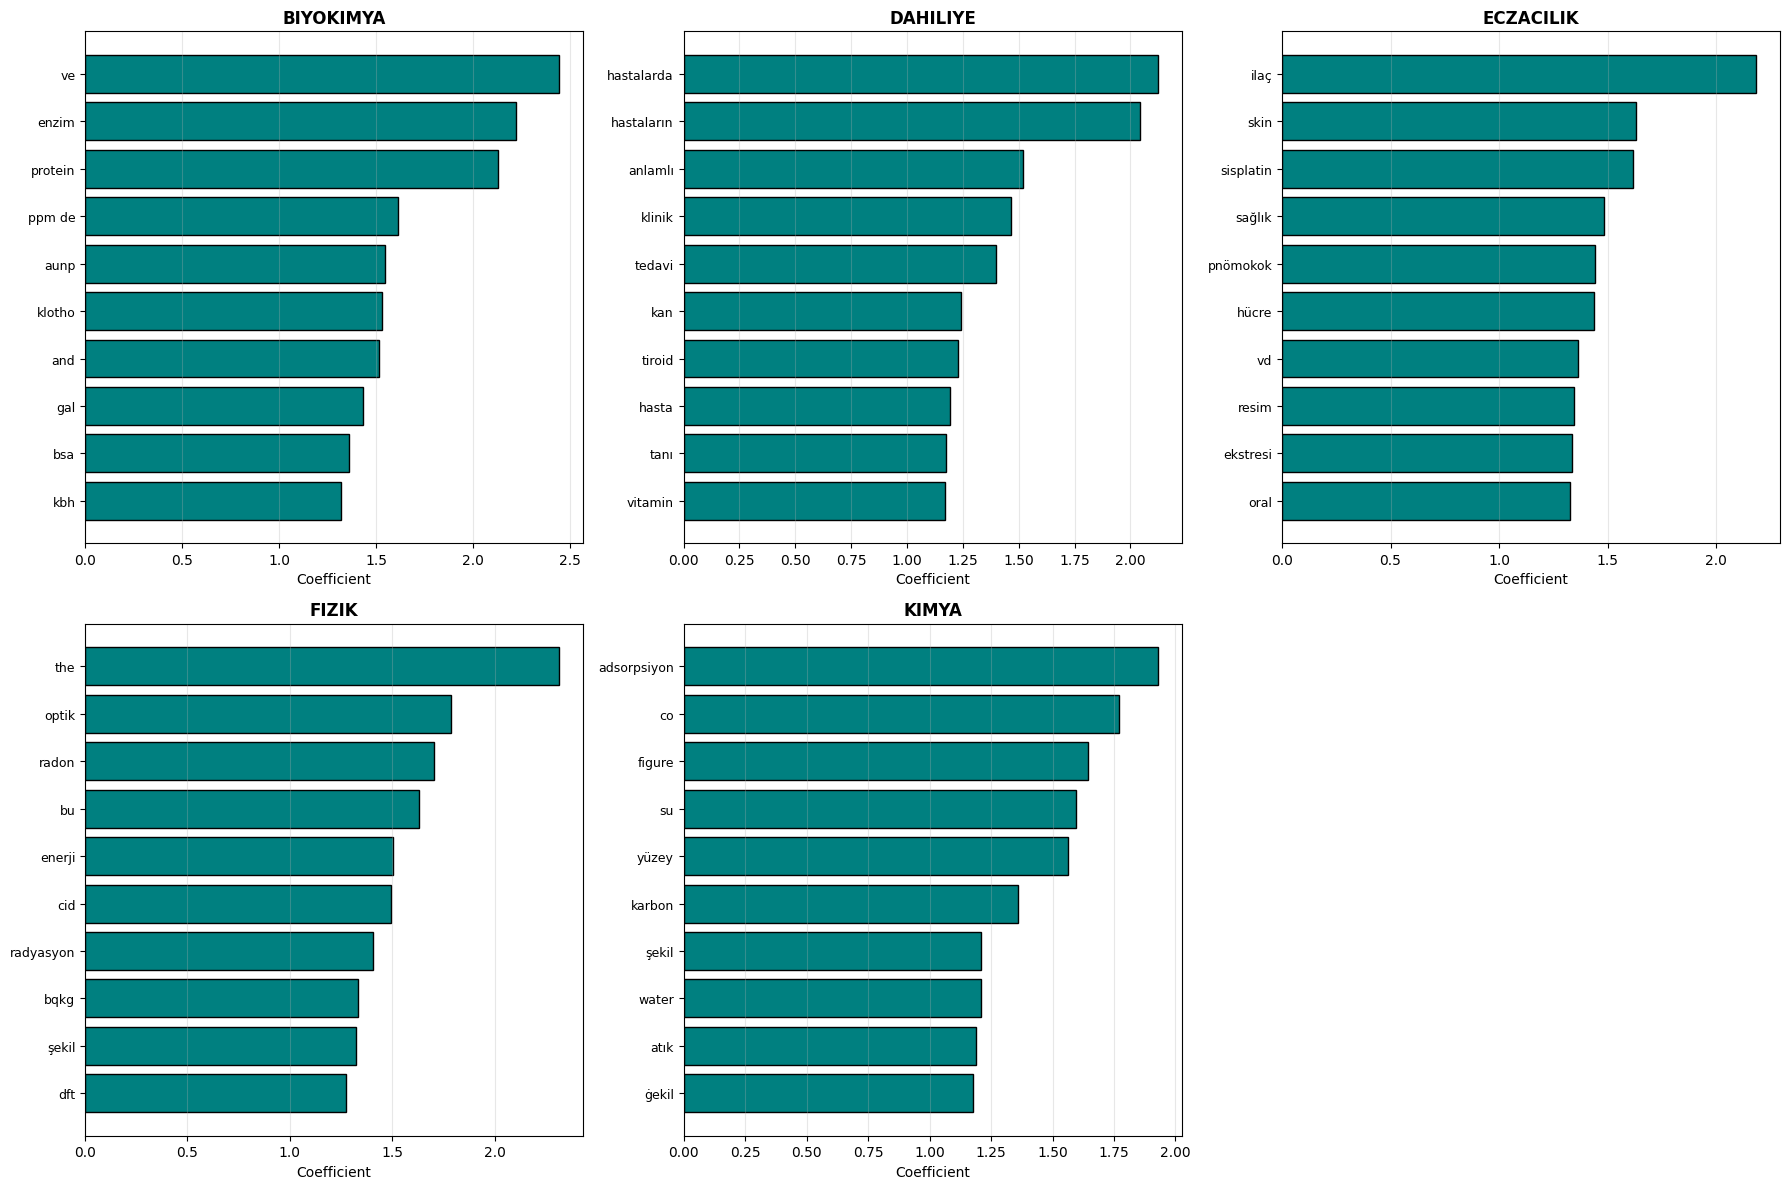

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import uniform
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/tez_dataset.csv")
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Shape:", X_train_tfidf.shape)
print("\nHİPERPARAMETRE OPTİMİZASYONU - Logistic Regression")

param_distributions = {
    'C': uniform(0.01, 10),
    'solver': ['lbfgs', 'liblinear']
}

lr_random = RandomizedSearchCV(
    LogisticRegression(max_iter=2000),
    param_distributions=param_distributions,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

start_time = time.time()
lr_random.fit(X_train_tfidf, y_train)
optimization_time = time.time() - start_time

print(f"\nOptimizasyon Süresi: {optimization_time:.2f} saniye")
print("\nEn iyi parametreler:")
for param, value in lr_random.best_params_.items():
    print(f"   {param}: {value}")

print(f"\nCross-validation accuracy: {lr_random.best_score_:.4f}")

y_pred = lr_random.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=sorted(y_test.unique()))

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()))
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

feature_names = tfidf.get_feature_names_out()
coefficients = lr_random.best_estimator_.coef_[0]

top_indices = np.argsort(coefficients)[-20:]

plt.figure(figsize=(10,8))
plt.barh(range(len(top_indices)), coefficients[top_indices])
plt.yticks(range(len(top_indices)), [feature_names[i] for i in top_indices])
plt.xlabel("Coefficient Value")
plt.title("Top 20 En Önemli Kelime")
plt.tight_layout()
plt.show()

best_model = lr_random.best_estimator_
print("TÜM KATEGORİLER İÇİN EN ÖNEMLİ KELİMELER")

feature_names = tfidf.get_feature_names_out()
classes = lr_random.best_estimator_.classes_
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, category in enumerate(classes):
    coefficients = lr_random.best_estimator_.coef_[idx]
    top_positive_indices = np.argsort(coefficients)[-10:]
    top_positive_features = [feature_names[i] for i in top_positive_indices]
    top_positive_coefs = coefficients[top_positive_indices]

    axes[idx].barh(range(len(top_positive_indices)), top_positive_coefs, color='teal', edgecolor='black')
    axes[idx].set_yticks(range(len(top_positive_indices)))
    axes[idx].set_yticklabels(top_positive_features, fontsize=9)
    axes[idx].set_xlabel('Coefficient', fontsize=10)
    axes[idx].set_title(f'{category.upper()}', fontsize=12, fontweight='bold')
    axes[idx].grid(axis='x', alpha=0.3)

    print(f"\n🔹 {category.upper()} - En önemli 10 kelime:")
    for feature, coef in zip(top_positive_features, top_positive_coefs):
        print(f"   {feature:30s} → {coef:.4f}")

axes[5].axis('off')

plt.tight_layout()
plt.show()


**MODEL 2:DERİN ÖĞRENME MODELLERİ (Bi-LSTM & BERT)**

Mounted at /content/drive
DERIN OGRENME: Bi-LSTM vs BERT

Veri seti yuklendi: 534 kayit
Kategoriler: ['fizik' 'biyokimya' 'dahiliye' 'eczacılık' 'kimya']

Train: 427 | Test: 107

Kategori mapping:
   biyokimya -> 0
   dahiliye -> 1
   eczacılık -> 2
   fizik -> 3
   kimya -> 4
MODEL 1: Bidirectional LSTM
   Vocab size: 386600
   Train shape: (427, 200)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 419ms/step - accuracy: 0.2158 - loss: 1.6114 - val_accuracy: 0.1628 - val_loss: 1.6056 - learning_rate: 0.0010
Epoch 2/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 243ms/step - accuracy: 0.3216 - loss: 1.5944 - val_accuracy: 0.1512 - val_loss: 1.5969 - learning_rate: 0.0010
Epoch 3/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 227ms/step - accuracy: 0.3510 - loss: 1.5604 - val_accuracy: 0.1977 - val_loss: 1.5673 - learning_rate: 0.0010
Epoch 4/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 226ms/step - accuracy: 0.4209 - loss: 1.4335 - val_accuracy: 0.4186 - val_loss: 1.4110 - learning_rate: 0.0010
Epoch 5/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 329ms/step - accuracy: 0.5782 - loss: 1.2629 - val_accuracy: 0.3605 - val_loss: 1.2418 - learning_rate: 0.0010
Epoch 6/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 293ms/step - accuracy: 0.6422 - loss: 0.9898 - val_accuracy: 0.6279 - val_loss: 1.0158 - learning_rate: 0.0010
Epoch 7/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 221ms/step - accuracy: 0.6532 - loss: 0.9013 - 

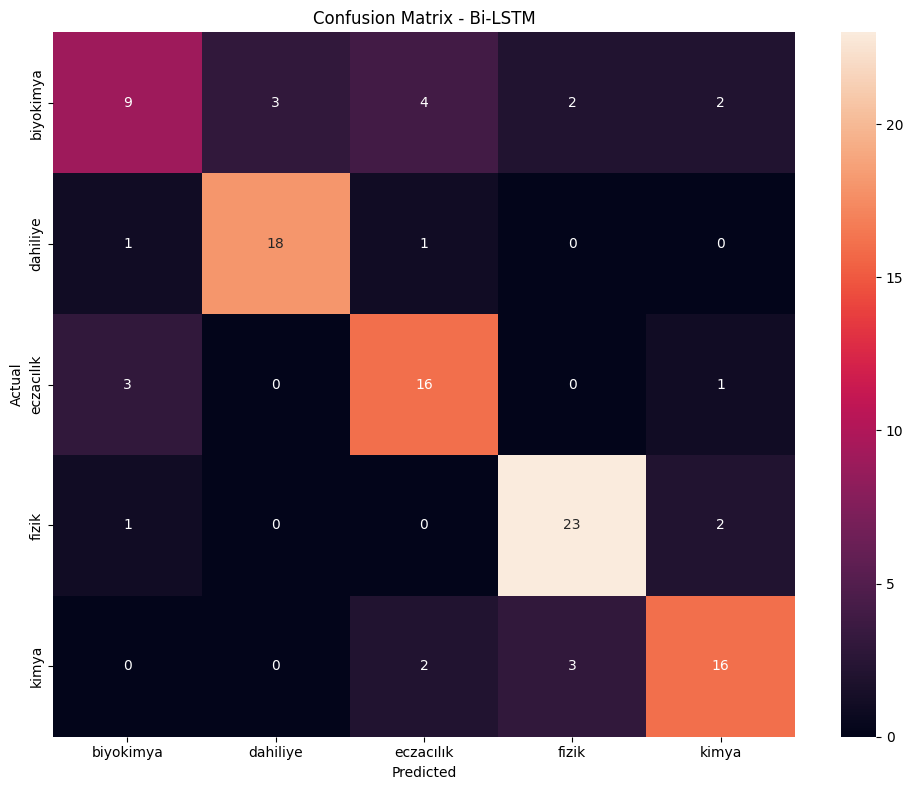

MODEL 2: BERT (BERTurk) - Transfer Learning


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

   Train shape: torch.Size([427, 256])
   Test shape: torch.Size([107, 256])
   Device: cpu


model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/2
  Train Loss: 1.5734 | Train Acc: 0.2951
  Val Acc: 0.4766

Epoch 2/2
  Train Loss: 1.1682 | Train Acc: 0.5433
  Val Acc: 0.7290

BERT Test Accuracy: 0.7290 (72.90%)

BERT Classification Report:
              precision    recall  f1-score   support

   biyokimya       0.56      0.45      0.50        20
    dahiliye       0.78      0.90      0.84        20
   eczacılık       0.71      0.75      0.73        20
       fizik       0.90      0.69      0.78        26
       kimya       0.67      0.86      0.75        21

    accuracy                           0.73       107
   macro avg       0.73      0.73      0.72       107
weighted avg       0.73      0.73      0.72       107



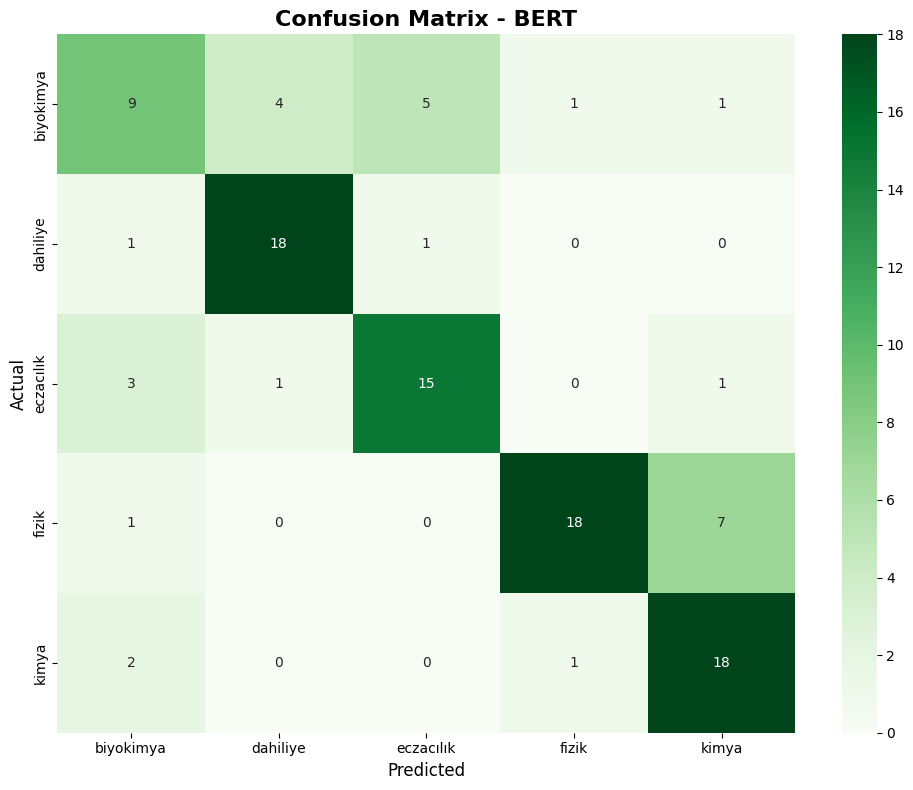

Bi-LSTM vs BERT KARSILASTIRMASI
         Model  Accuracy              Type
       Bi-LSTM  0.766355         RNN-based
BERT (BERTurk)  0.728972 Transformer-based


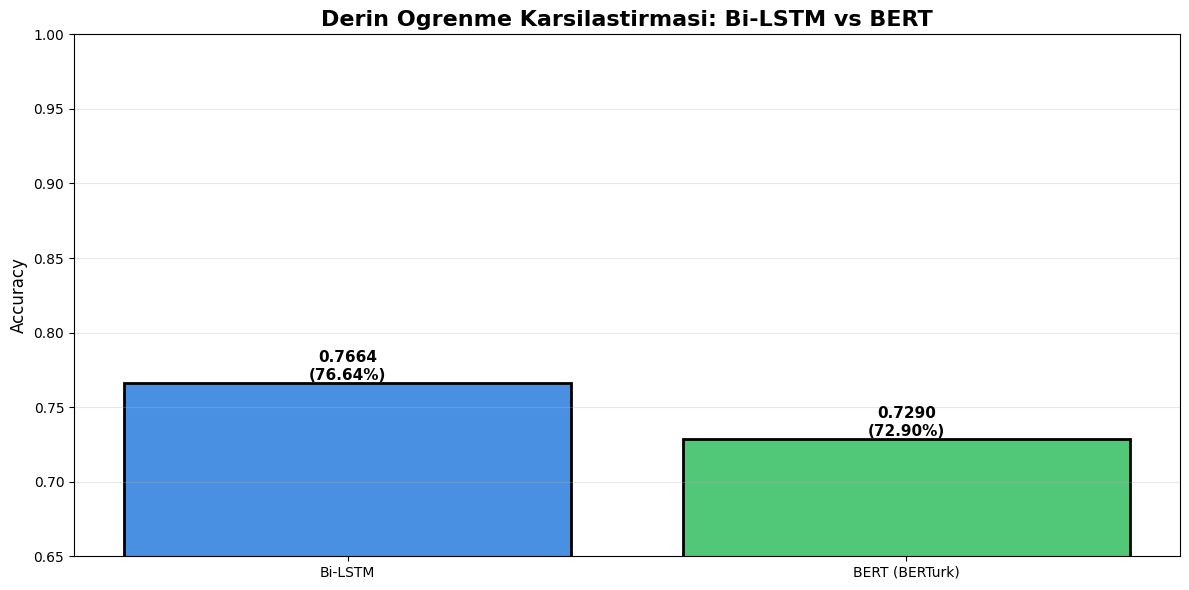

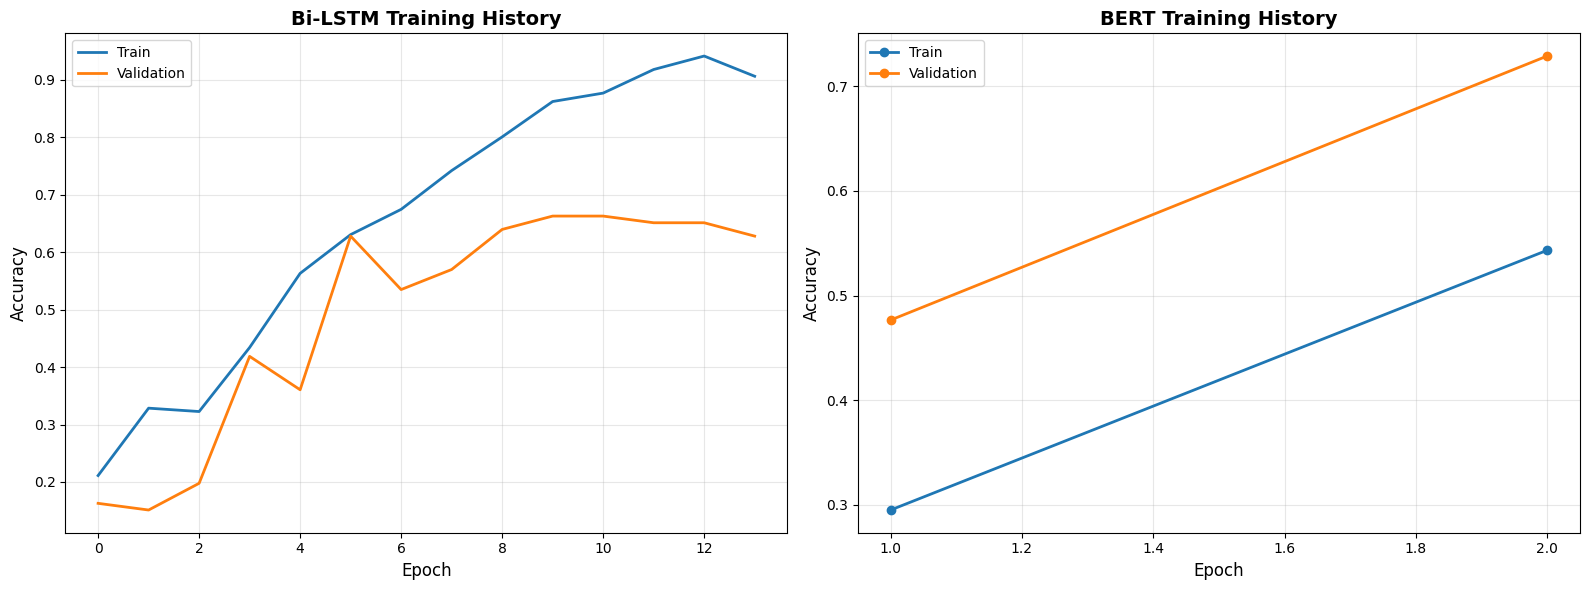


EN IYI MODEL: Bi-LSTM - 0.7664

SONUCLAR:
   accuracy_bilstm = 0.7664
   accuracy_bert = 0.7290


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from google.colab import drive
drive.mount('/content/drive')

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("DERIN OGRENME: Bi-LSTM vs BERT")

df = pd.read_csv("/content/drive/MyDrive/tez_dataset.csv")

print(f"\nVeri seti yuklendi: {len(df)} kayit")
print(f"Kategoriler: {df['label'].unique()}")

X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("\nKategori mapping:")
for i, label in enumerate(le.classes_):
    print(f"   {label} -> {i}")

print("MODEL 1: Bidirectional LSTM")
max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>", lower=True)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

print(f"   Vocab size: {len(tokenizer.word_index)}")
print(f"   Train shape: {X_train_pad.shape}")

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=1)

model_bilstm = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(64, dropout=0.2)),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(len(le.classes_), activation="softmax")
], name="BiLSTM_Model")

model_bilstm.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model_bilstm.summary()

history_bilstm = model_bilstm.fit(
    X_train_pad, y_train_encoded,
    epochs=25,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

y_pred_bilstm = model_bilstm.predict(X_test_pad, verbose=0)
y_pred_bilstm_classes = np.argmax(y_pred_bilstm, axis=1)
accuracy_bilstm = accuracy_score(y_test_encoded, y_pred_bilstm_classes)
print(f"\nBi-LSTM Test Accuracy: {accuracy_bilstm:.4f} ({accuracy_bilstm*100:.2f}%)")
print("\nBi-LSTM Classification Report:")
print(classification_report(y_test_encoded, y_pred_bilstm_classes, target_names=le.classes_))

cm_bilstm = confusion_matrix(y_test_encoded, y_pred_bilstm_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_bilstm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Bi-LSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()
print("MODEL 2: BERT (BERTurk) - Transfer Learning")


!pip install transformers torch -q

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW

tokenizer_bert = AutoTokenizer.from_pretrained('dbmdz/bert-base-turkish-cased')

train_encodings = tokenizer_bert(
    X_train.tolist(),
    max_length=256,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

test_encodings = tokenizer_bert(
    X_test.tolist(),
    max_length=256,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

print(f"   Train shape: {train_encodings['input_ids'].shape}")
print(f"   Test shape: {test_encodings['input_ids'].shape}")

train_dataset = TensorDataset(
    train_encodings['input_ids'],
    train_encodings['attention_mask'],
    torch.tensor(y_train_encoded)
)

test_dataset = TensorDataset(
    test_encodings['input_ids'],
    test_encodings['attention_mask'],
    torch.tensor(y_test_encoded)
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"   Device: {device}")

model_bert = AutoModelForSequenceClassification.from_pretrained(
    'dbmdz/bert-base-turkish-cased',
    num_labels=len(le.classes_)
).to(device)

optimizer = AdamW(model_bert.parameters(), lr=2e-5)

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total

def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids, attention_mask, labels = [b.to(device) for b in batch]
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

num_epochs = 2
train_accs = []
val_accs = []

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_epoch(model_bert, train_loader, optimizer)

    val_preds, val_labels = evaluate(model_bert, test_loader)
    val_acc = accuracy_score(val_labels, val_preds)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Acc: {val_acc:.4f}")

y_pred_bert_classes, y_test_bert = evaluate(model_bert, test_loader)
accuracy_bert = accuracy_score(y_test_bert, y_pred_bert_classes)

print(f"\nBERT Test Accuracy: {accuracy_bert:.4f} ({accuracy_bert*100:.2f}%)")
print("\nBERT Classification Report:")
print(classification_report(y_test_bert, y_pred_bert_classes, target_names=le.classes_))

cm_bert = confusion_matrix(y_test_bert, y_pred_bert_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_bert, annot=True, fmt="d", cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - BERT", fontsize=16, fontweight='bold')
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.tight_layout()
plt.show()

print("Bi-LSTM vs BERT KARSILASTIRMASI")

comparison = pd.DataFrame({
    "Model": ["Bi-LSTM", "BERT (BERTurk)"],
    "Accuracy": [accuracy_bilstm, accuracy_bert],
    "Type": ["RNN-based", "Transformer-based"]
}).sort_values("Accuracy", ascending=False)

print(comparison.to_string(index=False))

plt.figure(figsize=(12, 6))
colors = ['#4A90E2', '#50C878']
bars = plt.bar(comparison["Model"], comparison["Accuracy"],
               color=colors, edgecolor="black", linewidth=2)
plt.title("Derin Ogrenme Karsilastirmasi: Bi-LSTM vs BERT",
          fontsize=16, fontweight='bold')
plt.ylabel("Accuracy", fontsize=12)
plt.ylim([0.65, 1.0])
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., height,
             f"{height:.4f}\n({height*100:.2f}%)",
             ha="center", va="bottom", fontweight="bold", fontsize=11)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(history_bilstm.history["accuracy"], label="Train", linewidth=2)
axes[0].plot(history_bilstm.history["val_accuracy"], label="Validation", linewidth=2)
axes[0].set_title("Bi-LSTM Training History", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Accuracy", fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, num_epochs+1), train_accs, label="Train", linewidth=2, marker='o')
axes[1].plot(range(1, num_epochs+1), val_accs, label="Validation", linewidth=2, marker='o')
axes[1].set_title("BERT Training History", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Accuracy", fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nEN IYI MODEL: {comparison.iloc[0]['Model']} - {comparison.iloc[0]['Accuracy']:.4f}")
print(f"\nSONUCLAR:")
print(f"   accuracy_bilstm = {accuracy_bilstm:.4f}")
print(f"   accuracy_bert = {accuracy_bert:.4f}")

